<a href="https://colab.research.google.com/github/Kavya-Ramisetti/Kavya-Ramisetti/blob/main/currencyvision_data_collection_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💹 CurrencyVision — Dataset Collection
**GMR Institute of Technology | Foreign Currency Exchange Rate Prediction**

This notebook downloads 10 years (2015–2025) of **daily** exchange rate data for:
- INR / USD
- INR / EUR
- INR / GBP

Then cleans, validates and saves CSV files ready for ARIMA, LSTM and Hybrid models.

## Step 1 — Install Required Packages

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

# Only yfinance needs installing — everything else is pre-installed in Colab
!pip install yfinance --quiet
print('✅ yfinance installed')

✅ yfinance installed


## Step 2 — Import Libraries

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['text.color']       = '#e6edf3'
plt.rcParams['axes.labelcolor']  = '#e6edf3'
plt.rcParams['xtick.color']      = '#8b949e'
plt.rcParams['ytick.color']      = '#8b949e'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

print('✅ Libraries imported')

✅ Libraries imported


## Step 3 — Download Exchange Rate Data (2015–2025)

In [6]:
# Date range
START_DATE = '2015-01-01'
END_DATE   = '2025-03-01'

# Yahoo Finance tickers
# INR=X        → 1 USD = ? INR  (direct)
# EURINR=X     → 1 EUR = ? INR  (direct)
# GBPINR=X     → 1 GBP = ? INR  (direct)

PAIRS = {
    'INR_USD': 'INR=X',
    'INR_EUR': 'EURINR=X',
    'INR_GBP': 'GBPINR=X'
}

raw_data = {}

for pair_name, ticker in PAIRS.items():
    print(f'📥 Downloading {pair_name} ({ticker})...')
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if df.empty:
        print(f'  ⚠️  No data returned for {ticker}')
    else:
        raw_data[pair_name] = df
        print(f'  ✅ {len(df)} rows downloaded  |  {df.index[0].date()} → {df.index[-1].date()}')

print('\n✅ Download complete!')

📥 Downloading INR_USD (INR=X)...
  ✅ 2648 rows downloaded  |  2015-01-01 → 2025-02-28
📥 Downloading INR_EUR (EURINR=X)...
  ✅ 2649 rows downloaded  |  2015-01-01 → 2025-02-28
📥 Downloading INR_GBP (GBPINR=X)...
  ✅ 2649 rows downloaded  |  2015-01-01 → 2025-02-28

✅ Download complete!


## Step 4 — Inspect Raw Data

In [7]:
for pair, df in raw_data.items():
    print(f'\n===== {pair} =====')
    print(df[['Open','High','Low','Close','Volume']].tail(5).to_string())
    print(f'Shape: {df.shape}')
    print(f'Missing values:\n{df.isnull().sum()}')


===== INR_USD =====
Price            Open       High        Low      Close Volume
Ticker          INR=X      INR=X      INR=X      INR=X  INR=X
Date                                                         
2025-02-24  86.529404  86.751099  86.504799  86.529404      0
2025-02-25  86.690102  87.252403  86.681999  86.690102      0
2025-02-26  87.081200  87.188797  87.030998  87.081200      0
2025-02-27  87.162201  87.426399  87.094803  87.162201      0
2025-02-28  87.327003  87.542000  87.264801  87.327003      0
Shape: (2648, 5)
Missing values:
Price   Ticker
Close   INR=X     0
High    INR=X     0
Low     INR=X     0
Open    INR=X     0
Volume  INR=X     0
dtype: int64

===== INR_EUR =====
Price            Open       High        Low      Close   Volume
Ticker       EURINR=X   EURINR=X   EURINR=X   EURINR=X EURINR=X
Date                                                           
2025-02-24  89.401001  91.059998  89.401001  90.498001        0
2025-02-25  90.610001  91.587997  90.600998  

## Step 5 — Clean & Process Data

In [8]:
def clean_dataframe(df, pair_name):
    """
    Clean exchange rate dataframe:
    - Keep only Close price (most important for forecasting)
    - Rename column to pair name
    - Handle multi-level columns from yfinance
    - Fill missing values (forward fill then back fill)
    - Remove duplicate dates
    - Sort by date
    """
    # Handle multi-level columns from newer yfinance versions
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Keep Close price only
    close = df[['Close']].copy()
    close.columns = [pair_name]

    # Sort index
    close = close.sort_index()

    # Remove duplicate dates
    close = close[~close.index.duplicated(keep='first')]

    # Forward fill then backward fill missing values
    close = close.ffill().bfill()

    # Remove any remaining NaN rows
    close = close.dropna()

    # Make sure index is DatetimeIndex
    close.index = pd.to_datetime(close.index)
    close.index.name = 'Date'

    return close


clean_data = {}
for pair, df in raw_data.items():
    clean_data[pair] = clean_dataframe(df, pair)
    print(f'✅ {pair}: {len(clean_data[pair])} rows after cleaning')
    print(f'   Range: {clean_data[pair].index[0].date()} → {clean_data[pair].index[-1].date()}')
    print(f'   Min: {clean_data[pair].values.min():.4f}  |  Max: {clean_data[pair].values.max():.4f}  |  Mean: {clean_data[pair].values.mean():.4f}\n')

✅ INR_USD: 2648 rows after cleaning
   Range: 2015-01-01 → 2025-02-28
   Min: 61.3510  |  Max: 87.5883  |  Mean: 73.0612

✅ INR_EUR: 2649 rows after cleaning
   Range: 2015-01-01 → 2025-02-28
   Min: 65.8870  |  Max: 93.7550  |  Mean: 81.3461

✅ INR_GBP: 2649 rows after cleaning
   Range: 2015-01-01 → 2025-02-28
   Min: 79.4690  |  Max: 112.1842  |  Mean: 96.0006



## Step 6 — Statistical Summary

In [9]:
print('=' * 60)
print('DATASET SUMMARY')
print('=' * 60)

for pair, df in clean_data.items():
    display_name = pair.replace('_', '/')
    stats = df.describe()
    print(f'\n📊 {display_name}')
    print(f'  Total rows   : {len(df)}')
    print(f'  Date range   : {df.index[0].date()} to {df.index[-1].date()}')
    print(f'  Mean         : {stats.loc["mean"].values[0]:.4f}')
    print(f'  Std Dev      : {stats.loc["std"].values[0]:.4f}')
    print(f'  Min          : {stats.loc["min"].values[0]:.4f}')
    print(f'  Max          : {stats.loc["max"].values[0]:.4f}')
    print(f'  Missing      : {df.isnull().sum().values[0]}')

DATASET SUMMARY

📊 INR/USD
  Total rows   : 2648
  Date range   : 2015-01-01 to 2025-02-28
  Mean         : 73.0612
  Std Dev      : 7.0048
  Min          : 61.3510
  Max          : 87.5883
  Missing      : 0

📊 INR/EUR
  Total rows   : 2649
  Date range   : 2015-01-01 to 2025-02-28
  Mean         : 81.3461
  Std Dev      : 6.8149
  Min          : 65.8870
  Max          : 93.7550
  Missing      : 0

📊 INR/GBP
  Total rows   : 2649
  Date range   : 2015-01-01 to 2025-02-28
  Mean         : 96.0006
  Std Dev      : 7.3010
  Min          : 79.4690
  Max          : 112.1842
  Missing      : 0


## Step 7 — Visualize All 3 Currency Pairs

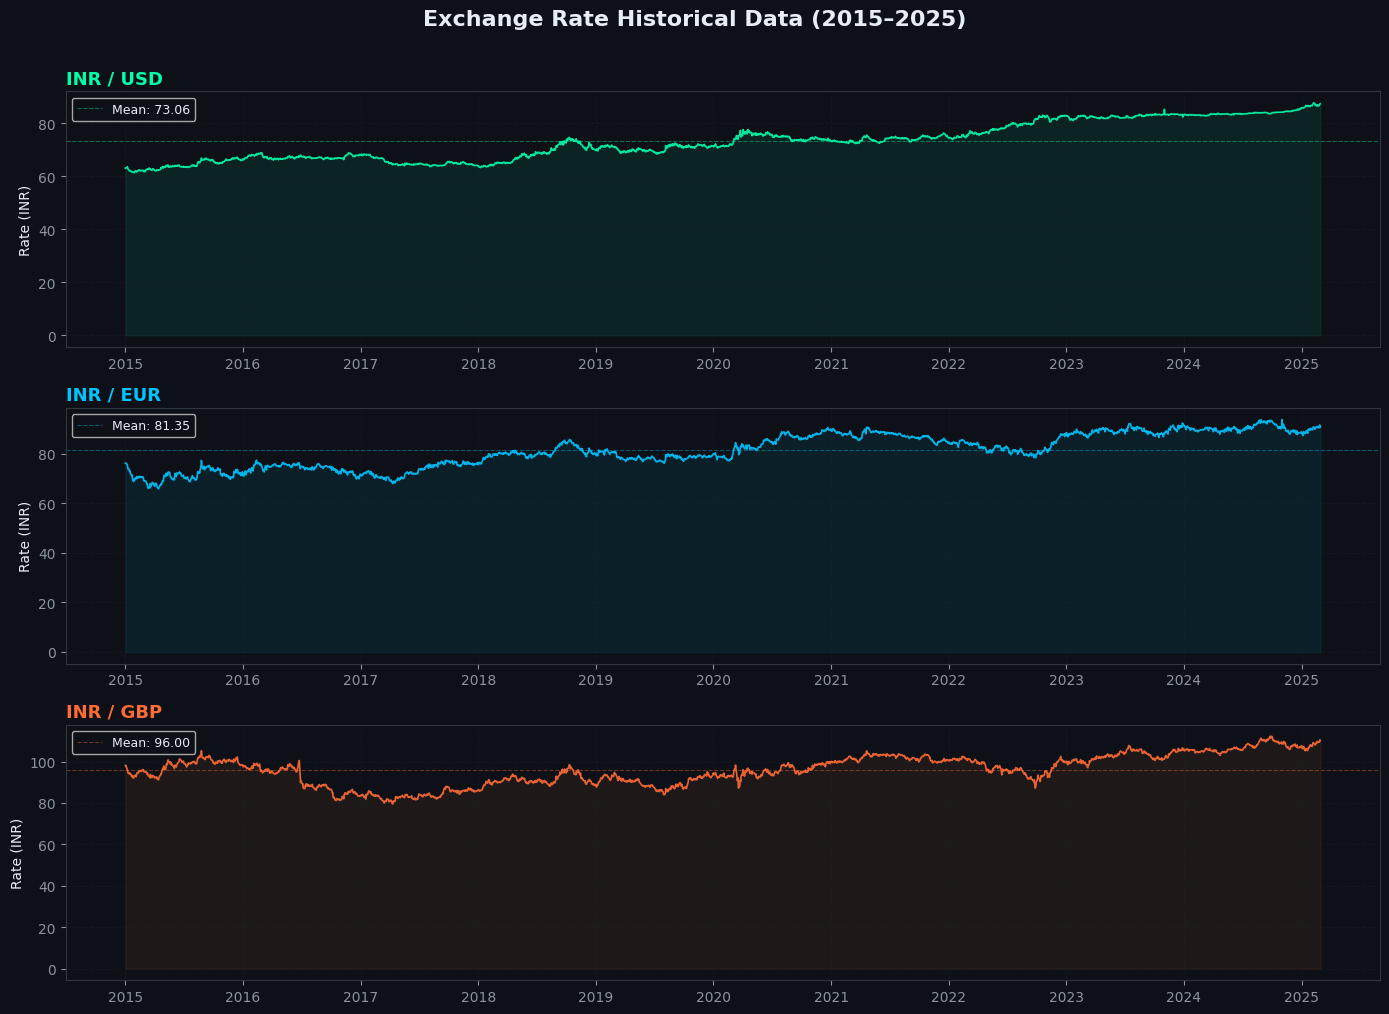

✅ Plot saved as exchange_rates_plot.png


In [10]:
colors = ['#00ffaa', '#00c4ff', '#ff6b35']
labels = ['INR / USD', 'INR / EUR', 'INR / GBP']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle('Exchange Rate Historical Data (2015–2025)', fontsize=16, fontweight='bold', color='#e6edf3', y=1.01)

for ax, (pair, df), color, label in zip(axes, clean_data.items(), colors, labels):
    ax.plot(df.index, df.values, color=color, linewidth=1.2, alpha=0.9)
    ax.fill_between(df.index, df.values.flatten(), alpha=0.08, color=color)
    ax.set_title(label, fontsize=13, fontweight='bold', color=color, loc='left')
    ax.set_ylabel('Rate (INR)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    # Highlight min/max
    yvals = df.values.flatten()
    ax.axhline(y=yvals.mean(), color=color, linestyle='--', alpha=0.4, linewidth=0.8, label=f'Mean: {yvals.mean():.2f}')
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('exchange_rates_plot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Plot saved as exchange_rates_plot.png')

## Step 8 — Check for Stationarity (ADF Test)

In [11]:
from statsmodels.tsa.stattools import adfuller

print('ADF Stationarity Test')
print('(p < 0.05 → stationary, p > 0.05 → non-stationary / needs differencing for ARIMA)\n')
print('-' * 55)

for pair, df in clean_data.items():
    result = adfuller(df.values.flatten(), autolag='AIC')
    p_val  = result[1]
    status = '✅ Stationary' if p_val < 0.05 else '⚠️  Non-stationary (use d=1 in ARIMA)'
    print(f'{pair.replace("_","/"):12} | ADF Stat: {result[0]:8.4f} | p-value: {p_val:.4f} | {status}')

ADF Stationarity Test
(p < 0.05 → stationary, p > 0.05 → non-stationary / needs differencing for ARIMA)

-------------------------------------------------------
INR/USD      | ADF Stat:  -0.3738 | p-value: 0.9144 | ⚠️  Non-stationary (use d=1 in ARIMA)
INR/EUR      | ADF Stat:  -1.4318 | p-value: 0.5669 | ⚠️  Non-stationary (use d=1 in ARIMA)
INR/GBP      | ADF Stat:  -1.5926 | p-value: 0.4873 | ⚠️  Non-stationary (use d=1 in ARIMA)


## Step 9 — Save CSV Files

In [12]:
import os
os.makedirs('data', exist_ok=True)

saved_files = []
for pair, df in clean_data.items():
    filename = f'data/{pair}_2015_2025_daily.csv'
    df.to_csv(filename)
    saved_files.append(filename)
    print(f'✅ Saved: {filename}  ({len(df)} rows)')

# Also save a combined file
combined = pd.concat([df for df in clean_data.values()], axis=1)
combined.columns = ['INR_USD', 'INR_EUR', 'INR_GBP']
combined = combined.ffill().bfill()
combined.to_csv('data/ALL_PAIRS_combined.csv')
print(f'\n✅ Combined file saved: data/ALL_PAIRS_combined.csv  ({len(combined)} rows, {combined.shape[1]} columns)')
print('\n📁 All files saved to /data/ folder')
print('   You can download them from the Files panel on the left in Colab (📁 icon)')

✅ Saved: data/INR_USD_2015_2025_daily.csv  (2648 rows)
✅ Saved: data/INR_EUR_2015_2025_daily.csv  (2649 rows)
✅ Saved: data/INR_GBP_2015_2025_daily.csv  (2649 rows)

✅ Combined file saved: data/ALL_PAIRS_combined.csv  (2649 rows, 3 columns)

📁 All files saved to /data/ folder
   You can download them from the Files panel on the left in Colab (📁 icon)


## Step 10 — Preview Final Data

In [13]:
print('COMBINED DATASET — Last 10 rows')
print('=' * 45)
display(combined.tail(10))

print(f'\nTotal shape: {combined.shape}')
print(f'Date range : {combined.index[0].date()} → {combined.index[-1].date()}')
print(f'Missing    : {combined.isnull().sum().to_dict()}')
print('\n✅ Dataset is ready for ARIMA, LSTM and Hybrid modelling!')

COMBINED DATASET — Last 10 rows


,INR_USD,INR_EUR,INR_GBP
Date,,,
2025-02-17,86.434601,90.808998,108.810471
2025-02-18,86.854797,90.989998,109.615967
2025-02-19,86.887199,90.696999,109.757637
2025-02-20,86.872803,90.472000,109.262535
2025-02-21,86.451202,90.841003,109.531250
2025-02-24,86.529404,90.498001,109.300934
2025-02-25,86.690102,90.603996,109.366714
2025-02-26,87.081200,91.594002,110.256592
2025-02-27,87.162201,91.316002,110.462158



Total shape: (2649, 3)
Date range : 2015-01-01 → 2025-02-28
Missing    : {'INR_USD': 0, 'INR_EUR': 0, 'INR_GBP': 0}

✅ Dataset is ready for ARIMA, LSTM and Hybrid modelling!


## ✅ Summary — Files Generated

| File | Description |
|------|-------------|
| `data/INR_USD_2015_2025_daily.csv` | INR/USD daily close prices |
| `data/INR_EUR_2015_2025_daily.csv` | INR/EUR daily close prices |
| `data/INR_GBP_2015_2025_daily.csv` | INR/GBP daily close prices |
| `data/ALL_PAIRS_combined.csv` | All 3 pairs in one file |
| `exchange_rates_plot.png` | Visual of all 3 series |

## ➡️ Next Steps
1. Download the CSV files (Files panel → right-click → Download)
2. Push to your GitHub repo
3. Use `ALL_PAIRS_combined.csv` as the main input for your models
4. Next notebook: **Data Preprocessing + ARIMA Model**